In [4]:
# 앙상블 학습
# 보팅 분류기(Voting Classifier)
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
lr_clf = LogisticRegression(solver='liblinear')
dt_clf = DecisionTreeClassifier(random_state=0)
knn_clf = KNeighborsClassifier(n_neighbors=5)
vo_clf = VotingClassifier(estimators=[('LR',lr_clf), ('DT',dt_clf), ('KNN', knn_clf)], voting='soft')
# pdf에는 knn이 빠져있음(pdf가 잘못됨)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2 , random_state= 0 )
vo_clf.fit(X_train , y_train)
pred = vo_clf.predict(X_test)
print(f'Voting 분류기 정확도: {accuracy_score(y_test,pred):.4f}')

Voting 분류기 정확도: 0.9649


In [ ]:
# 랜덤포레스트 실습
from sklearn.ensemble import RandomForestClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2 , random_state= 0)

rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f'랜덤 포레스트 정확도: {accuracy:.4f}')

랜덤 포레스트 정확도: 0.9649


In [8]:
rf_clf.feature_importances_

array([0.03699612, 0.01561296, 0.06016409, 0.0371452 , 0.0063401 ,
       0.00965994, 0.0798662 , 0.08669071, 0.00474992, 0.00417092,
       0.02407355, 0.00548033, 0.01254423, 0.03880038, 0.00379521,
       0.00435162, 0.00452503, 0.00556905, 0.00610635, 0.00528878,
       0.09556258, 0.01859305, 0.17205401, 0.05065305, 0.00943096,
       0.01565491, 0.02443166, 0.14202709, 0.00964898, 0.01001304])

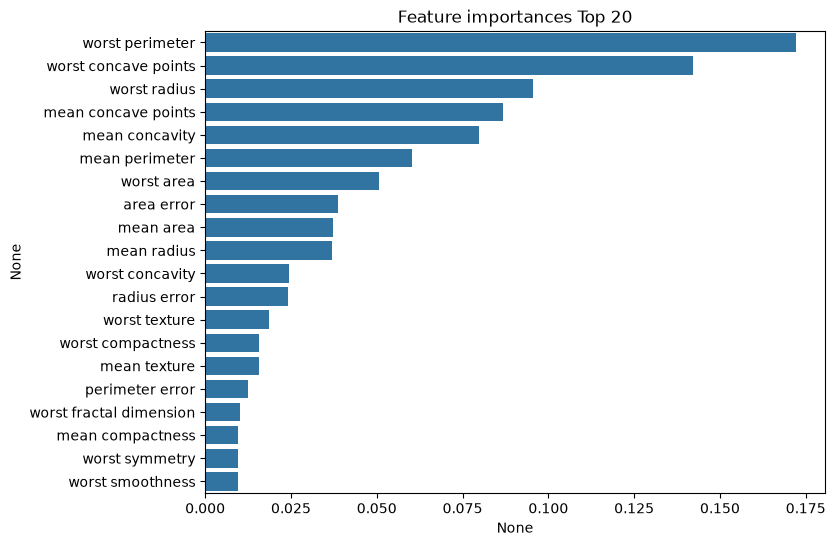

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ftr_importances_values = rf_clf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=cancer.feature_names )
ftr_top20 = ftr_importances.sort_values(ascending = False)[:20]
plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x = ftr_top20, y = ftr_top20.index)
plt.show()
plt.draw()

In [10]:
rf_clf.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=209652396),
 DecisionTreeClassifier(max_features='sqrt', random_state=398764591),
 DecisionTreeClassifier(max_features='sqrt', random_state=924231285),
 DecisionTreeClassifier(max_features='sqrt', random_state=1478610112),
 DecisionTreeClassifier(max_features='sqrt', random_state=441365315),
 DecisionTreeClassifier(max_features='sqrt', random_state=1537364731),
 DecisionTreeClassifier(max_features='sqrt', random_state=192771779),
 DecisionTreeClassifier(max_features='sqrt', random_state=1491434855),
 DecisionTreeClassifier(max_features='sqrt', random_state=1819583497),
 DecisionTreeClassifier(max_features='sqrt', random_state=530702035),
 DecisionTreeClassifier(max_features='sqrt', random_state=626610453),
 DecisionTreeClassifier(max_features='sqrt', random_state=1650906866),
 DecisionTreeClassifier(max_features='sqrt', random_state=1879422756),
 DecisionTreeClassifier(max_features='sqrt', random_state=1277901399),
 DecisionTree

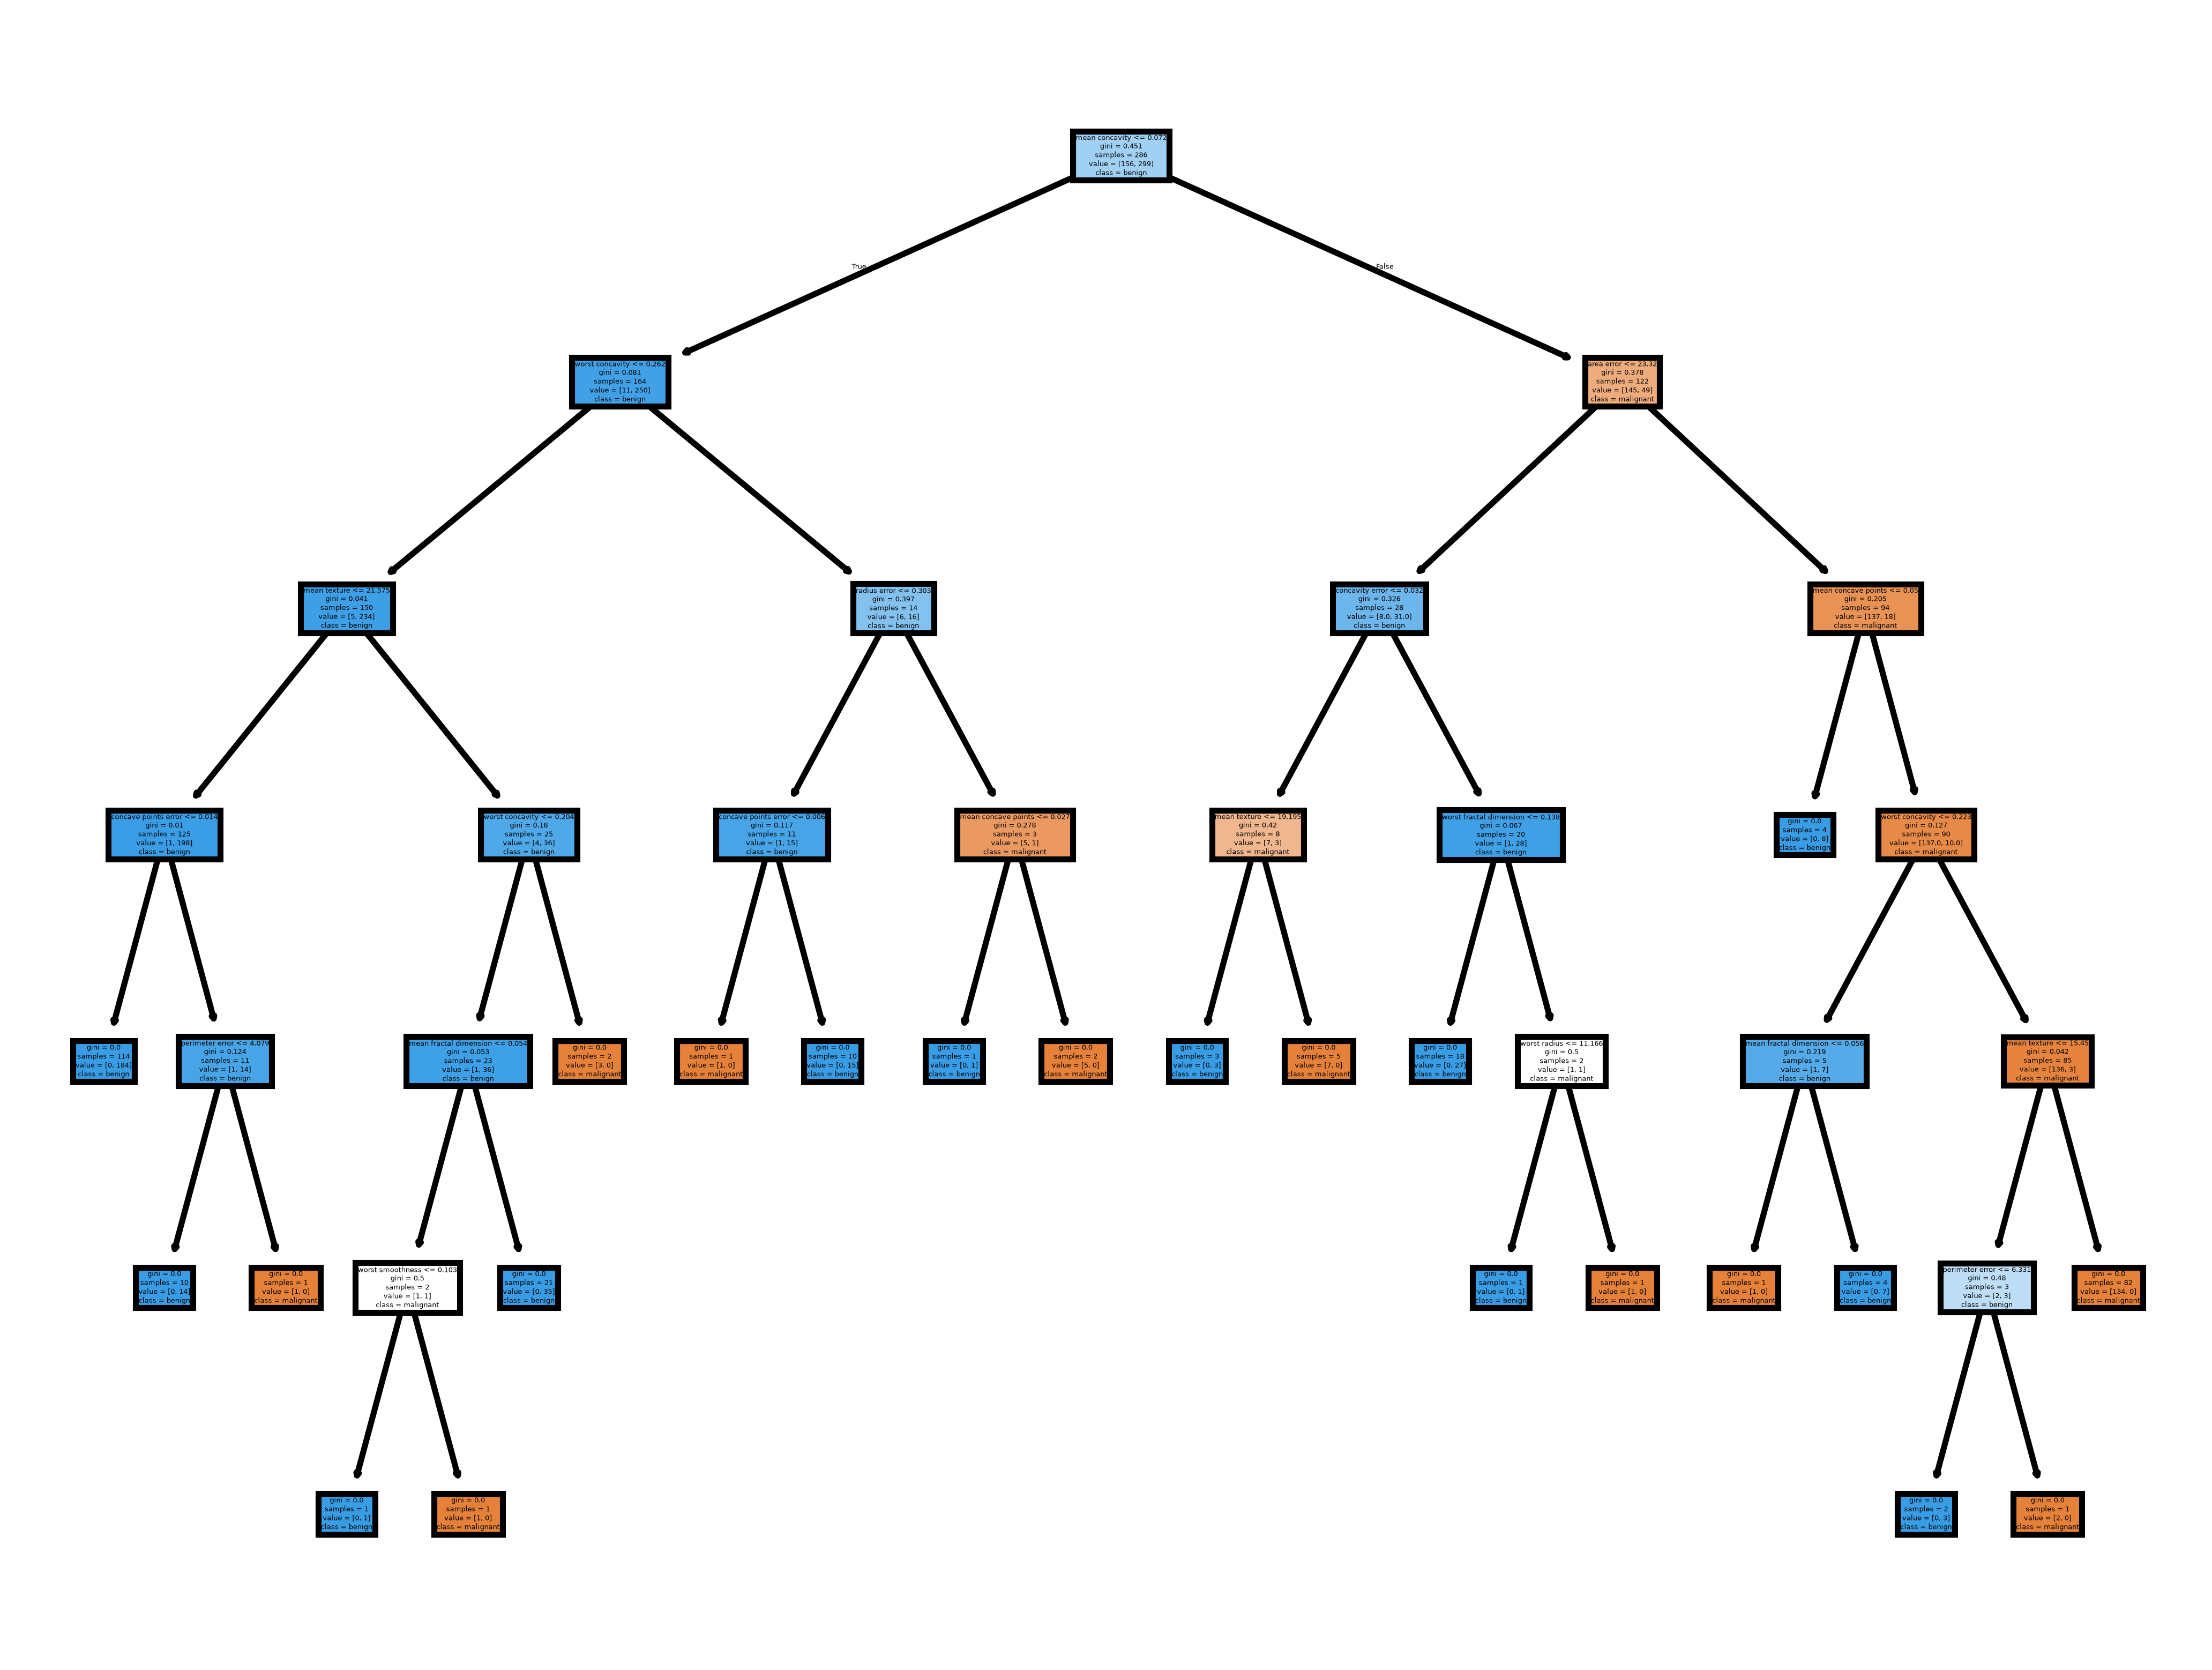

In [15]:
from sklearn.tree import plot_tree

plt.figure(dpi=800)
plot_tree(rf_clf.estimators_[0], filled=True, 
          feature_names=cancer.feature_names,
          class_names=cancer.target_names)
plt.show()

In [ ]:
# GBM(Gradient Boosting Machine) 
# 일단 지금은 점차 학습을 점차 개선해나가면서 모델이 오차를 줄일 수 있도록 학습해 나갈 수 있는 모델이다 정도만 알기
from sklearn.ensemble import GradientBoostingClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state= 0)
gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)
print(f'GBM 정확도: {gb_accuracy:.4f}')

GBM 정확도: 0.9649


In [17]:
!pip install xgboost

In [18]:
import xgboost

In [19]:
from xgboost import XGBClassifier
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=0)

# 미리 검증 데이터를 나눔
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

In [21]:
xgb_wrapper.fit(X_train, y_train)
pred = xgb_wrapper.predict(X_test)

In [24]:
evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals)
pred = xgb_wrapper.predict(X_test)

# 위 셀과 결과 모양이 달라짐

[0]	validation_0-logloss:0.57152	validation_1-logloss:0.60181
[1]	validation_0-logloss:0.50611	validation_1-logloss:0.54213
[2]	validation_0-logloss:0.45161	validation_1-logloss:0.49128
[3]	validation_0-logloss:0.40595	validation_1-logloss:0.44903
[4]	validation_0-logloss:0.36611	validation_1-logloss:0.41357
[5]	validation_0-logloss:0.33177	validation_1-logloss:0.38228
[6]	validation_0-logloss:0.30206	validation_1-logloss:0.35508
[7]	validation_0-logloss:0.27664	validation_1-logloss:0.32839
[8]	validation_0-logloss:0.25357	validation_1-logloss:0.31076
[9]	validation_0-logloss:0.23307	validation_1-logloss:0.29200
[10]	validation_0-logloss:0.21437	validation_1-logloss:0.27189
[11]	validation_0-logloss:0.19812	validation_1-logloss:0.26075
[12]	validation_0-logloss:0.18324	validation_1-logloss:0.24468
[13]	validation_0-logloss:0.17005	validation_1-logloss:0.23431
[14]	validation_0-logloss:0.15838	validation_1-logloss:0.22394
[15]	validation_0-logloss:0.14815	validation_1-logloss:0.21267
[1

In [26]:
from xgboost import XGBClassifier
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, eval_metric='logloss', 
                            early_stopping_rounds=10)

evals = [(X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals)
pred = xgb_wrapper.predict(X_test)

[0]	validation_0-logloss:0.60161
[1]	validation_0-logloss:0.54306
[2]	validation_0-logloss:0.49349
[3]	validation_0-logloss:0.45145
[4]	validation_0-logloss:0.41684
[5]	validation_0-logloss:0.38519
[6]	validation_0-logloss:0.35977
[7]	validation_0-logloss:0.33714
[8]	validation_0-logloss:0.31402
[9]	validation_0-logloss:0.29952
[10]	validation_0-logloss:0.28329
[11]	validation_0-logloss:0.26567
[12]	validation_0-logloss:0.24968
[13]	validation_0-logloss:0.24073
[14]	validation_0-logloss:0.22912
[15]	validation_0-logloss:0.22148
[16]	validation_0-logloss:0.21310
[17]	validation_0-logloss:0.20936
[18]	validation_0-logloss:0.20002
[19]	validation_0-logloss:0.19384
[20]	validation_0-logloss:0.19170
[21]	validation_0-logloss:0.18305
[22]	validation_0-logloss:0.17686
[23]	validation_0-logloss:0.17346
[24]	validation_0-logloss:0.17331
[25]	validation_0-logloss:0.17028
[26]	validation_0-logloss:0.16384
[27]	validation_0-logloss:0.15891
[28]	validation_0-logloss:0.15614
[29]	validation_0-loglos

In [27]:
xgb_wrapper.best_iteration

84

In [28]:
accuracy_score(y_test, pred)

0.9736842105263158

In [29]:
# 로지스틱 회귀 실습

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [31]:
cancer = load_breast_cancer()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train , X_test, y_train , y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)
print(f'accuracy: {acc:.3f}, roc_auc:{auc:.3f}')

accuracy: 0.977, roc_auc:0.995


In [32]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    pred = lr_clf.predict(X_test)
    pred_proba = lr_clf.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, pred_proba)

    print(f'solver: {solver}, accuracy: {acc:.3f}, roc_auc:{auc:.3f}')

solver: lbfgs, accuracy: 0.977, roc_auc:0.995
solver: liblinear, accuracy: 0.982, roc_auc:0.995
solver: newton-cg, accuracy: 0.977, roc_auc:0.995
solver: sag, accuracy: 0.982, roc_auc:0.995
solver: saga, accuracy: 0.982, roc_auc:0.995


In [ ]:
from sklearn.model_selection import GridSearchCV

params={'solver':['liblinear', 'lbfgs'], 'penalty':['l2', 'l1'], 'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()
grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3 )
grid_clf.fit(data_scaled, cancer.target)

print(f'최적 하이퍼 파라미터:{grid_clf.best_params_}')
print(f'최대 평균 정확도:{grid_clf.best_score_:.3f}')

# warning이 겁나많이 뜨는 것을 확인 할 수 있음
# warning을 끌 수 있긴 한데 무슨일이 생긴지 모르니까 굳이 끄진 않았음

최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
최대 평균 정확도:0.979


c:\Users\samsung1\git_project\samsung_practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\samsung1\git_project\samsung_practice\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

In [35]:
# 최근접 이웃(K-nearest neighbors)

from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

cancer = load_breast_cancer()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train , X_test, y_train , y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
pred_proba = knn.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, pred_proba)

print(f'accuracy: {acc:.3f}, roc_auc:{auc:.3f}')

accuracy: 0.953, roc_auc:0.992
